# Differentiable predictive control (DPC) for PDE Control using TI-DeepONet in Neuromancer

Recreating [DPC](https://www.sciencedirect.com/science/article/pii/S0959152422000981) using TI-DeepONet (Time-integrated Deep Operator Network) Heat equation notebook example in Neuromancer from (https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/tree/main).

Here, we use the trained TI-DON (see example [examples/neural_operators/Part_8_TIDON_HEAT.ipynb](../neural_operators/Part_8_TIDON_HEAT.ipynb)) 

This example presents a framework to do DPC for PDE control implemented in Neuromancer.

<img src="https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/blob/main/DPC_NO.png?raw=true" width="700">
<!-- <img src="https://arxiv.org/html/2505.17341v2/x2.png?raw=true" width="700"> -->

The goal is to learn a feedback control policy for a distributed parameter system.  
A neural operator provides a differentiable model of the physics, which allows gradients of long rollouts to be computed with respect to policy parameters.

### References

[1] [Sarkar, D. R., Drgoňa, J., & Goswami, S. (2025). Learning to Control PDEs with Differentiable Predictive Control and Time-Integrated Neural Operators. arXiv preprint arXiv:2511.08992.](https://arxiv.org/abs/2511.08992)


## Physical system: 1D Heat Equation

The dynamics are governed by

$$
\frac{\partial u}{\partial t}
=
\alpha \frac{\partial^2 u}{\partial x^2}
+
f(x,t),
\qquad x \in [0,1], \quad t \in [0, 0.4],
$$

with homogeneous Dirichlet boundary conditions and thermal diffusivity

$$
\alpha = 0.1.
$$

Here:

- $u(x,t)$ is the temperature field  
- $f(x,t)$ is the external forcing (control input)

---

## TI-DON parametrization

Instead of solving the PDE numerically inside the optimizer, a neural operator is trained to approximate the **instantaneous time derivative**.

### Learned dynamics model

$$
\mathcal{G}_\theta : (u(t), f(t)) \mapsto \partial_t u.
$$

Time evolution is then obtained by integrating this derivative with **RK4**:

$$
u_{k+1} = \mathrm{RK4}\big(\mathcal{G}_\theta, u_k, f_k, \Delta t\big).
$$

This makes the simulator differentiable and inexpensive compared to classical solvers.

---

## Control parameterization

The forcing is not optimized at every spatial location.  
Instead, it is expanded in a low-dimensional actuator basis.

$$
f(x,t)
=
\sum_{i=1}^{n}
f_i(t)
\exp\!\left(
- \frac{(x-\mu_i)^2}{2\sigma^2}
\right).
$$

### Actuator layout

- number of actuators: $n = 4$  
- locations: $\mu_i \in \{0.2, 0.4, 0.6, 0.8\}$  
- width: $\sigma = 0.1$

### Control variables

The learnable quantities are the amplitudes $f_i(t)$, with bounds

$$
|f_i(t)| \le 40.
$$

Therefore, at each time step the action is a **4-dimensional vector**.

---

## Control policy learning

Differentiable Predictive Control learns a **control policy**:

$$
f_k = \pi_{\mathbf{W}}(u_k, \xi_k),
$$

where

- $\pi_{\mathbf{W}}$ is a neural network  
- $\xi_k$ contains references or other time-varying parameters

---

## Training objective

After discretizing space into $n_x$ grid points and time into $N$ steps,
the policy parameters $\mathbf{W}$ are trained to match the **final state**
of the rollout to a desired target.

$$
\min_{\mathbf{W}}
\;
\mathbb{E}_{u_0, \xi}
\left[
\frac{1}{n_x}
\sum_{i=1}^{n_x}
\big(u_N^i - u_{N,\text{ref}}^i\big)^2
\right].
$$

No intermediate stage penalties are used.

---

## Rollout dynamics

The trajectory is generated recursively using the learned model:

$$
u_{k+1} =
\mathrm{RK4}\big(\mathcal{G}_\theta, u_k, f_k, \Delta t\big),
\qquad
f_k = \pi_{\mathbf{W}}(u_k, \xi_k).
$$

Although the loss is applied only at $k=N$, gradients propagate through
all time steps.


### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random seed
seed = 1234
torch.manual_seed(seed)
# NumPy random seed
np.random.seed(seed)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


# Training TI-DeepONet

### Using the TI-DON Dynamics Model $\mathcal{G}_\theta$ in NeuroMANCER

The code here to train the TI-DON dynamics model is the same as [examples/neural_operators/Part_8_TIDON_HEAT.ipynb](../neural_operators/Part_8_TIDON_HEAT.ipynb). Skip to the "Differentiable Predictive Control" section if you need.

We train $\mathcal{G}_\theta$, which maps the current state and control to the time derivative:

- $\mathcal{G}_\theta(u_k, f_k) \rightarrow \partial_t u_k$

The model is then used inside the rollout integrator to advance the state:

- $u_{k+1} = \mathrm{RK4}(\mathcal{G}_\theta, u_k, f_k)$



## Data loading for HEAT equation

* **Method:** Finite Difference Method (FDM) with the unconditionally stable **Crank-Nicolson scheme**.
* **Dataset:** 3000 samples with initial conditions from a Gaussian Random Field (GRF).
* **Resolution:** Spatial $\Delta x = 10^{-2}$, Temporal $\Delta t = 10^{-3}$.

The training and testing datasets for all heat equation PDE systems is available at this [link](https://livejohnshopkins-my.sharepoint.com/:f:/g/personal/droysar1_jh_edu/ElrQ5bd7MKRLv5bfn3_Rg9gBBbJHXQHOztZ37scwJGjbqQ?e=aOTLQC). 

Download `heat_smooth_f_dataset.npz`


In [ ]:
data_path = "pathto/datasets/heat_smooth_f_dataset.npz"

In [4]:
dataset = np.load(data_path)  # total 3000 samples available
n_data_load = 500  # samples or number of trajectories to load, original has 500

solutions = torch.from_numpy(
    dataset["solutions"][:n_data_load]
)  # shape: (samples, T+1, N)
controls = torch.from_numpy(dataset["controls"][:n_data_load])  # shape: (samples, T, 4)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1)  # shape: (N, 1)
dt = float(np.asarray(dataset["dt"]).item())  # Python scalar for Neuromancer integrators


print(f"Loaded {n_data_load}/{dataset['solutions'].shape[0]} samples:")
print("solutions:", solutions.shape)  # (samples, T+1, N)
print("controls:", controls.shape)  # (samples, T, 4)
print("x:", x_cord.shape)
print("dt:", dt)


Loaded 500/3000 samples:
solutions: torch.Size([500, 401, 100])
controls: torch.Size([500, 400, 4])
x: torch.Size([100, 1])
dt: 0.001


In [5]:
# Sequences for one-step training
U = solutions  # (samples, T+1, N)
F = controls  # (samples, T, 4)
# split
train_frac = 0.8
n_train = int(train_frac * U.shape[0])

U_train, U_test = U[:n_train], U[n_train:]
F_train, F_test = F[:n_train], F[n_train:]

### Time handling for one-step `System` training


In [6]:
def flatten_time(U_seq, F_seq, nsteps=1):
    """
    Flatten time dimension of trajectory data for n-step training samples.

    Args:
        U_seq (Tensor): Shape (S, T+1, N) - sequence of states.
        F_seq (Tensor): Shape (S, T, F) - sequence of forcings.
        nsteps (int): Number of steps ahead for the target state.

    Returns:
        u_t (Tensor): Shape (S*(T-nsteps+1), 1, N) - current state.
        f_t (Tensor): Shape (S*(T-nsteps+1), nsteps, F) - forcing sequence.
        u_next (Tensor): Shape (S*(T-nsteps+1), N) - target state after nsteps.
    """
    S, T_plus_1, N = U_seq.shape
    T = T_plus_1 - 1
    F = F_seq.shape[-1]

    if nsteps > T:
        raise ValueError(f"nsteps={nsteps} exceeds sequence length T={T}")

    u_t = U_seq[:, : T - nsteps + 1, :]  # (S, T-n+1, N)
    u_next = U_seq[:, nsteps : T + 1, :]  # (S, T-n+1, N)

    f_t_seq = [F_seq[:, i : T - nsteps + 1 + i, :] for i in range(nsteps)]
    f_t = torch.stack(f_t_seq, dim=2)  # (S, T-n+1, nsteps, F)

    # Flatten samples
    u_t = u_t.reshape(-1, 1, N)
    f_t = f_t.reshape(-1, nsteps, F)
    u_next = u_next.reshape(-1, N)

    return u_t, f_t, u_next

u_t_tr, f_t_tr, u_next_tr = flatten_time(U_train, F_train)
u_t_te, f_t_te, u_next_te = flatten_time(U_test, F_test)

### **TI-DeepONet Architecture**

The TI-DeepONet is modified to handle control problems by splitting the "Branch" network into two separate parts,  State Branch ($b^u$) and Control Branch ($b^f$). The Trunk Network ($t$) encodes the coordinates.

The network predicts the **time derivative** ($\partial u / \partial t$)  It does this by taking the dot product of the combined branches and the trunk:

$$
\frac{\partial u}{\partial t} \approx \sum_{j=1}^{p} \left[ b_j^u(u^i) \odot b_j^f(f^i) \right] t_j(\zeta)
$$

### Dataset preparation for the Trainer

In [7]:
from neuromancer.dataset import DictDataset

trunk_grid = torch.as_tensor(x_cord, dtype=torch.float32).reshape(-1, 1)

def build_dictdataset_flat(u_t, f_t, u_next, name):
    trunk_inputs = trunk_grid.expand(u_t.shape[0], -1, -1)  # (S*T, 100, 1)
    return DictDataset(
        {
            "u_t": u_t.float(),  # (S*T, 1, 100)
            "f_t": f_t.float(),  # (S*T, 1, 4)
            "outputs": u_next.float(),  # (S*T, 100)
            "trunk_inputs": trunk_inputs.float(),
        },
        name=name,
    )


train_ds = build_dictdataset_flat(u_t_tr, f_t_tr, u_next_tr, "train")
test_ds = build_dictdataset_flat(u_t_te, f_t_te, u_next_te, "test")


In [8]:
# check dimensions
print("Dimensions check train:")
print("u_t (step):", train_ds.datadict["u_t"].shape)
print("f_t (step):", train_ds.datadict["f_t"].shape)
print("outputs (u_next):", train_ds.datadict["outputs"].shape)
print("trunk_inputs:", train_ds.datadict["trunk_inputs"].shape)

print("Dimensions check test:")
print("u_t (step):", test_ds.datadict["u_t"].shape)
print("f_t (step):", test_ds.datadict["f_t"].shape)
print("outputs (u_next):", test_ds.datadict["outputs"].shape)
print("trunk_inputs:", test_ds.datadict["trunk_inputs"].shape)


Dimensions check train:
u_t (step): torch.Size([160000, 1, 100])
f_t (step): torch.Size([160000, 1, 4])
outputs (u_next): torch.Size([160000, 100])
trunk_inputs: torch.Size([160000, 100, 1])
Dimensions check test:
u_t (step): torch.Size([40000, 1, 100])
f_t (step): torch.Size([40000, 1, 4])
outputs (u_next): torch.Size([40000, 100])
trunk_inputs: torch.Size([40000, 100, 1])


In [9]:
batch_size = 75
print(f"batch_size: {batch_size}")

# Do this on device, as it needs to for Training
g_device = torch.Generator(device=device).manual_seed(seed)

steps_per_epoch = 1000
num_samples = steps_per_epoch * batch_size

g_device = torch.Generator(device=device).manual_seed(seed)

sampler = torch.utils.data.RandomSampler(
    train_ds,
    replacement=True,
    num_samples=num_samples,
    generator=g_device,
)


batch_size: 75


In [10]:
train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=sampler,
    collate_fn=train_ds.collate_fn,
    drop_last=True,
    shuffle=False,  # must be False when sampler is provided
)

test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size,
    collate_fn=test_ds.collate_fn,
    shuffle=False,
)


### Exporting DeepONet from DeepXDE in Neuromancer

Here, we use `dde.nn.MIONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`. 

Code: (https://deepxde.readthedocs.io/en/latest/_modules/deepxde/nn/pytorch/mionet.html#MIONetCartesianProd)


In [11]:
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

activation = {
    "branch1": "gelu",
    "branch2": "gelu",
    "trunk": "tanh",
}

hidden_dim = 100

layer_sizes_branch1 = [100, 128, 128, 128, hidden_dim]  # u_t: (B,100) -> (B,100)
layer_sizes_branch2 = [4, 32, 32, 32, hidden_dim]  # f_t: (B,4)   -> (B,100)
layer_sizes_trunk = [1, 64, 64, 64, hidden_dim]  # x:   (100,1) -> (100,100)

tidon = dde.nn.MIONetCartesianProd(
    layer_sizes_branch1=layer_sizes_branch1,
    layer_sizes_branch2=layer_sizes_branch2,
    layer_sizes_trunk=layer_sizes_trunk,
    activation=activation,
    kernel_initializer="Glorot normal",  # weight initialisation available in DeepXDE
    trunk_last_activation=True,  # matches the JAX trunk applying tanh after every Dense
    merge_operation="mul",  # y_func = y_func1 * y_func2
    layer_sizes_merger=None,  # no extra merger MLP
    layer_sizes_output_merger=None,  # keep dot-product einsum
)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


### `neuromancer.dynamics.integrators` compatibility for DeepONet

In [12]:
from neuromancer.modules.operators import DeepXDEWrapper, DeepXDEIntegratorWrapper

deeponet_wrapped = DeepXDEWrapper(
    model=tidon,
    is_cartesian=True,
    branch_keys=["u_t", "f_t"],
)

deeponet_integrator = DeepXDEIntegratorWrapper(
    model=deeponet_wrapped,
    trunk_inputs=trunk_grid,
)

In [13]:
from neuromancer.dynamics import integrators
from neuromancer.system import Node

dt = float(np.asarray(dt).item())
fxRK4 = integrators.DiffEqIntegrator(deeponet_integrator, h=dt, method="rk4")
node_rk4 = Node(
    fxRK4,
    ["u_t", "f_t"],
    ["u_t"],
    name="TI_DON + RK4",
)


In [14]:
from neuromancer.system import System

nsteps = 1  # one-step training
dynamics_model = System(
    nodes=[node_rk4],
    name="Dynamics_system",
    nsteps=nsteps,
)

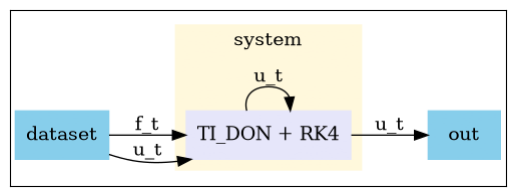

In [15]:
dynamics_model.show()

### Setting up the NeuroMANCER Problem, with approporiate loss function

**Loss Function.** We utilize a fully data-driven approach using Mean Squared Error (MSE). The loss is calculated by comparing the ground truth data $u_{t+1}$ against the predicted state $\hat{u}_{t+1}$, which is obtained by integrating the DeepONet output through an RK4 step:

$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{u}_{t+1}^{(i)} - u_{t+1}^{(i)} \right)^2
$$

In [16]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.constraint import Objective

var_y_est = variable("u_t")[
    :, 1, :
]  # predicted u_t+1, compare with outputs (which is (B,100)
var_y_true = variable("outputs")

# MSE over one-step prediction
mse_var = (var_y_est - var_y_true) ** 2
mse_obj = Objective(mse_var, metric=torch.mean, name="mse_loss")

loss = PenaltyLoss(objectives=[mse_obj], constraints=[])


In [17]:
# Use System for one-step training
problem_tidon = Problem(
    nodes=[dynamics_model],
    loss=loss,
    #   grad_inference=True
)


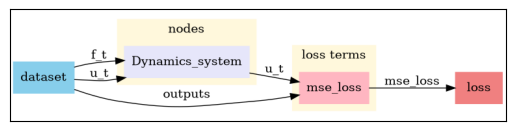

In [18]:
problem_tidon.show()  # graphviz library needed for graph visualization

### Training the TIDON

In [19]:
from torch.optim.lr_scheduler import LambdaLR
from neuromancer.callbacks import Callback

# result_dir = './'
epochs_tidon = int(10)  # 10 passes of 1000 steps each
log_every = 100
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

The custom callback `StepLRSchedulerCallback` updates the learning rate at every training step (batch) and optionally logs the training loss at a fixed step interval.

It gives the printed format:
`epoch: <epoch> step: <step_in_epoch> <loss_name>: <loss_value>`

In [20]:
class StepLRSchedulerCallback(Callback):
    """
    Scheduler that steps every batch end, and logs loss every `log_every`.

    Args:
        scheduler: Learning rate scheduler to step.
        log_every: Frequency of logging loss (in number of steps). If 0, no logging.
        global_step: Internal counter for total steps taken.
        epoch_step: Counter for steps within the current epoch.
        step_indices: List of global step indices where loss was logged.
        step_losses: List of losses corresponding to the logged step indices.
    """

    def __init__(self, scheduler, log_every=1):
        super().__init__()
        self.scheduler = scheduler
        self.log_every = log_every
        self.global_step = 0
        self._last_epoch = None
        self.epoch_step = 0
        self.step_indices = []
        self.step_losses = []

    def end_batch(self, trainer, output):
        if self._last_epoch != trainer.current_epoch:
            self._last_epoch = trainer.current_epoch
            self.epoch_step = 0

        self.scheduler.step()

        if self.log_every and self.epoch_step % self.log_every == 0:
            loss = output.get(trainer.train_metric)
            if loss is not None:
                loss_val = loss.detach().cpu().item()
                lr = self.scheduler.get_last_lr()[0]
                print(
                    f"epoch: {trainer.current_epoch} step: {self.epoch_step} "
                    f"{trainer.train_metric}: {loss_val:.6g}"
                    f" lr: {lr:.2e}",
                    flush=True,
                )
                self.step_indices.append(self.global_step)
                self.step_losses.append(loss_val)

        self.epoch_step += 1
        self.global_step += 1


The learning rate is updated at each optimizer step using an exponential decay schedule,
$$
\eta_k = \eta_0 \, \gamma^{\,k / T},
$$
where $\eta_0$ is the base learning rate (`lr`), $ \gamma \in (0,1) $ is the decay rate (`decay_rate`), $ k $ denotes the optimizer step index, and $ T $ is the transition scale (`transition_steps`) controlling the decay speed.

In [21]:
def exponential_decay(step: int) -> float:
    """Exponential learning-rate decay applied per optimizer step."""
    return decay_rate ** (step / transition_steps)


In [22]:
from neuromancer.trainer import Trainer

problem_tidon = problem_tidon.to(device)

optimizer_tidon = torch.optim.Adam(problem_tidon.parameters(), lr=lr)

scheduler_tidon = LambdaLR(
    optimizer_tidon,
    lr_lambda=exponential_decay,
)

lr_callback_tidon = StepLRSchedulerCallback(
    scheduler_tidon,
    log_every=log_every,
)

trainer_tidon = Trainer(
    problem_tidon,
    train_data=train_loader,
    test_data=test_loader,
    optimizer=optimizer_tidon,          # important
    callback=lr_callback_tidon,         # scheduler goes here through callback
    epochs=epochs_tidon,
    epoch_verbose=1,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    test_metric="test_loss",
    device=device,
)


In [23]:
%%time
best_tidon_model = trainer_tidon.train()

epoch: 0 step: 0 train_loss: 0.000338611 lr: 1.00e-03
epoch: 0 step: 100 train_loss: 0.000117018 lr: 9.95e-04
epoch: 0 step: 200 train_loss: 5.56808e-05 lr: 9.89e-04
epoch: 0 step: 300 train_loss: 3.71137e-05 lr: 9.84e-04
epoch: 0 step: 400 train_loss: 3.1258e-05 lr: 9.79e-04
epoch: 0 step: 500 train_loss: 2.53722e-05 lr: 9.74e-04
epoch: 0 step: 600 train_loss: 1.99317e-05 lr: 9.69e-04
epoch: 0 step: 700 train_loss: 1.21485e-05 lr: 9.64e-04
epoch: 0 step: 800 train_loss: 8.13567e-06 lr: 9.59e-04
epoch: 0 step: 900 train_loss: 7.32281e-06 lr: 9.54e-04
epoch: 0  train_loss: 4.580720269586891e-05
epoch: 1 step: 0 train_loss: 7.68359e-06 lr: 9.49e-04
epoch: 1 step: 100 train_loss: 6.30001e-06 lr: 9.44e-04
epoch: 1 step: 200 train_loss: 5.77936e-06 lr: 9.39e-04
epoch: 1 step: 300 train_loss: 5.95618e-06 lr: 9.34e-04
epoch: 1 step: 400 train_loss: 4.20539e-06 lr: 9.29e-04
epoch: 1 step: 500 train_loss: 5.2977e-06 lr: 9.24e-04
epoch: 1 step: 600 train_loss: 4.7753e-06 lr: 9.19e-04
epoch: 1 st

In [24]:
# Freeze the trained dynamics model before DPC; only the policy is optimized.
problem_tidon.load_state_dict(best_tidon_model)
tidon.eval()
for p in tidon.parameters():
    p.requires_grad_(False)
print("model params require grad after freeze:", any(p.requires_grad for p in tidon.parameters()))

model params require grad after freeze: False


# Differentiable Predictive Control

Differentiable Predictive Control learns a **control policy**:

$$
f_k = \pi_{\mathbf{W}}(u_k, \xi_k),
$$

where

- $\pi_{\mathbf{W}}$ is a neural network  
- $\xi_k$ contains references or other time-varying parameters


## Training objective

After discretizing space into $n_x$ grid points and time into $N$ steps,
the policy parameters $\mathbf{W}$ are trained to match the **final state**
of the rollout to a desired target.

$$
\min_{\mathbf{W}}
\;
\mathbb{E}_{u_0, \xi}
\left[
\frac{1}{n_x}
\sum_{i=1}^{n_x}
\big(u_N^i - u_{N,\text{ref}}^i\big)^2
\right].
$$


## Data generation for control policy training

We generate data for the policy learning. Initialisation and finals are created using `generate_grf_pairs`.

In [25]:
import gpytorch

train_frac = 0.8  # train/test split
nsteps = 100  # 100 rollout steps for DPC, original paper uses 400

# GRF hyperparameters
length_scale = 0.2
variance = 1.0
num_modes = 64


In [26]:
def rbf_covariance_gpytorch(x_grid, lengthscale_eff, variance):
    """Compute RBF covariance using GPyTorch on CPU."""
    x = torch.tensor(x_grid, dtype=torch.float64).view(-1, 1)
    rbf_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=1)
    rbf_kernel.lengthscale = torch.tensor(float(lengthscale_eff), dtype=torch.float64)
    scale_kernel = gpytorch.kernels.ScaleKernel(rbf_kernel)
    scale_kernel.outputscale = torch.tensor(float(variance), dtype=torch.float64)
    with torch.no_grad():
        cov = scale_kernel(x).evaluate()
    return cov.cpu().numpy().astype(np.float64)


def create_1d_grf_zero_boundary(x_grid, lengthscale, variance, kernel_type, seed):
    """Generate a single 1D GRF sample with zero boundary conditions using an RBF kernel."""
    _ = kernel_type
    if seed is not None:
        np.random.seed(int(seed))

    x = np.asarray(x_grid, dtype=np.float64).reshape(-1)
    n_points = x.shape[0]
    if n_points < 3:
        raise ValueError("x_grid must have at least 3 points for interior sampling.")

    boundary_indices = [0, n_points - 1]
    interior_indices = list(range(1, n_points - 1))

    lengthscale = float(lengthscale)
    if lengthscale <= 0.0:
        raise ValueError("lengthscale must be positive.")
    span = float(x[-1] - x[0])
    lengthscale_eff = lengthscale * span if span != 0.0 else lengthscale

    cov_full = rbf_covariance_gpytorch(x, lengthscale_eff, variance)
    cov_full = cov_full + 1e-10 * np.eye(n_points)

    k_ii = cov_full[np.ix_(interior_indices, interior_indices)]
    k_ib = cov_full[np.ix_(interior_indices, boundary_indices)]
    k_bb = cov_full[np.ix_(boundary_indices, boundary_indices)]
    k_bb_inv = np.linalg.inv(k_bb)
    k_conditional = k_ii - k_ib @ k_bb_inv @ k_ib.T
    k_conditional = 0.5 * (k_conditional + k_conditional.T)

    eigvals, eigvecs = np.linalg.eigh(k_conditional)
    eigvals = np.maximum(eigvals, 1e-10)
    l_mat = eigvecs @ np.diag(np.sqrt(eigvals))
    z = np.random.randn(len(interior_indices))
    interior_vals = l_mat @ z

    grf = np.zeros(n_points, dtype=np.float64)
    grf[interior_indices] = interior_vals
    return grf.astype(np.float32)


def generate_grf_pairs(
    num_samples,
    x_cord,
    length_scale,
    variance,
    num_modes,
    seed,
):
    """Generate GRF (u0, u_tf) pairs, no train/test split."""
    _ = num_modes
    rng = np.random.default_rng(None if seed is None else int(seed))
    x_grid = np.asarray(x_cord, dtype=np.float32).reshape(-1)

    grf_inits = []
    grf_finals = []
    for _ in range(int(num_samples)):
        s1 = int(rng.integers(0, 10_000))
        s2 = int(rng.integers(0, 10_000))
        grf_init = create_1d_grf_zero_boundary(
            x_grid, length_scale, variance, "rbf", seed=s1
        )
        grf_final = create_1d_grf_zero_boundary(x_grid, 0.4, variance, "rbf", seed=s2)
        grf_inits.append(grf_init)
        grf_finals.append(grf_final)

    grf_inits = np.array(grf_inits, dtype=np.float32)
    grf_finals = np.array(grf_finals, dtype=np.float32)

    inits = torch.from_numpy(grf_inits)
    finals = torch.from_numpy(grf_finals)
    return inits, finals


`DictDataset` for Neuromancer data loading

In [27]:
# from neuromancer.dataset import DictDataset
def build_dictdataset_policy(inits, finals, x_cord, nsteps, name="policy_grf"):
    """
    inits:    (B, nx)
    finals:   (B, nx)
    x_cord:   (nx, 1)
    """

    if x_cord.dim() == 1:
        x_cord = x_cord.reshape(-1, 1)

    trunk_inputs = x_cord.unsqueeze(0).expand(inits.shape[0], -1, -1)

    # repeat u_tf across time to match rollout horizon
    u_t_final = finals[:, None, :].repeat(1, nsteps + 1, 1)  # (B, nsteps+1, nx)

    return DictDataset(
        {
            "u_t": inits[:, None, :].float(),  # (B, 1, nx)
            "u_tf": u_t_final.float(),  # (B, nsteps+1, nx)
            "trunk_inputs": trunk_inputs.float(),  # (B, nx, 1)
        },
        name=name,
    )


In [ ]:
# Number of samples for generating GRF pairs, original paper uses 500, we use 100 for faster experimentation
num_samples_policy = 100

# ---- prepare trunk grid ----
# trunk_grid = torch.as_tensor(x_cord, dtype=torch.float32).reshape(-1, 1)

# ---- generate GRF inits/finals (no split) ----
inits, finals = generate_grf_pairs(
    num_samples=num_samples_policy,
    x_cord=trunk_grid,  # same as trunk grid
    length_scale=length_scale,
    variance=variance,
    num_modes=num_modes,
    seed=seed,
)


In [29]:
# ---- split indices ----
num_train_policy = int(num_samples_policy * train_frac)
train_idx = torch.arange(0, num_train_policy, device="cpu")
test_idx = torch.arange(num_train_policy, num_samples_policy, device="cpu")

# ---- build train/test datasets ----
train_ds_policy = build_dictdataset_policy(
    inits[train_idx],
    finals[train_idx],
    x_cord=trunk_grid,
    nsteps=nsteps,
    name="train",
)

test_ds_policy = build_dictdataset_policy(
    inits[test_idx],
    finals[test_idx],
    x_cord=trunk_grid,
    nsteps=nsteps,
    name="test",
)

In [30]:
# check dimensions
print("Dimensions check train:")
print("u_t (step):", train_ds_policy.datadict["u_t"].shape)
print("u_tf (final state):", train_ds_policy.datadict["u_tf"].shape)
print("trunk_inputs:", train_ds_policy.datadict["trunk_inputs"].shape)

print("Dimensions check test:")
print("u_t (step):", test_ds_policy.datadict["u_t"].shape)
print("u_tf (final state):", test_ds_policy.datadict["u_tf"].shape)
print("trunk_inputs:", test_ds_policy.datadict["trunk_inputs"].shape)

Dimensions check train:
u_t (step): torch.Size([80, 1, 100])
u_tf (final state): torch.Size([80, 101, 100])
trunk_inputs: torch.Size([80, 100, 1])
Dimensions check test:
u_t (step): torch.Size([20, 1, 100])
u_tf (final state): torch.Size([20, 101, 100])
trunk_inputs: torch.Size([20, 100, 1])


### Create torch DataLoaders for the Trainer

In [31]:
batch_size = 75
print(f"batch_size: {batch_size}")

# Do this on device, as it needs to for Training
g_device = torch.Generator(device=device).manual_seed(seed)

batch_size: 75


Shuffling enables learning a representation of the gradient $\frac{\partial u}{\partial t}$, and not a sequence mapping a time-step to another time-step

Randomly sample from training data set 1000 times per epoch, with `replacement=True`. This means there's a chance to pick up the same data again. This fully random sampling allows efficient learning of the representation of the gradient.

In [32]:
steps_per_epoch = 100  # vary this to control how many samples are drawn per epoch, since we are sampling with replacement
num_samples = steps_per_epoch * batch_size

g_device = torch.Generator(device=device).manual_seed(seed)

sampler = torch.utils.data.RandomSampler(
    train_ds_policy,
    replacement=True,
    num_samples=num_samples,
    generator=g_device,
)

train_loader_policy = torch.utils.data.DataLoader(
    train_ds_policy,
    batch_size=batch_size,
    sampler=sampler,
    collate_fn=train_ds_policy.collate_fn,
    drop_last=True,
    shuffle=False,  # must be False when sampler is provided
)

test_loader_policy = torch.utils.data.DataLoader(
    test_ds_policy,
    batch_size=batch_size,
    collate_fn=test_ds_policy.collate_fn,
    shuffle=False,
)


## Initialise the MLP policy

The MLP policy from the original paper is provided here as `MLPControl`, which can be wrapped in a Neuromancer `Node`. A pure Neuromancer way to initialise the MLP is given in `MLP_bounds`. Noted differences:

### MLPControl vs MLP_bounds (key differences)

- **Output scaling**  
  - `MLPControl`: `tanh(x) * 40`  
  - `MLP_bounds`: built‑in bound with `min/max` (e.g. `[-40, 40]`)

- **Output bias**  
  - `MLPControl`: explicit learned `output_bias`  
  - `MLP_bounds`: no explicit output bias unless you add it manually

- **API shape**  
  - `MLPControl`: `forward(u_t, u_tf)` and does concat inside  
  - `MLP_bounds`: expects a single tensor → needs a wrapper to concat

- **Nonlinearity**  
  - `MLPControl`: uses `silu`  
  - `MLP_bounds`: configurable (`activations["gelu"]` etc.). `silu` not available

- **Capacity change if bias removed**  
  - Removing `output_bias` slightly reduces expressiveness.

### Custom MLPControl

In [33]:
class MLPControl(torch.nn.Module):
    """MLP control policy mapping (u_t, u_tf) to bounded controls."""

    def __init__(self, state_dim, control_dim, h_layers=None):
        super().__init__()
        self.state_dim = int(state_dim)
        self.control_dim = int(control_dim)
        if h_layers is None:
            h_layers = [128, 128, 128, self.control_dim]
        self.h_layers = [int(v) for v in h_layers]
        self.output_dim = int(self.control_dim)
        if self.h_layers[-1] != self.output_dim:
            raise ValueError("Last h_layers entry must match output_dim.")

        input_dim = self.state_dim * 2
        layers = []
        prev_dim = input_dim
        for width in self.h_layers:
            layers.append(torch.nn.Linear(prev_dim, width))
            prev_dim = width
        self.layers = torch.nn.ModuleList(layers)
        self.output_bias = torch.nn.Parameter(torch.zeros(self.output_dim))

    def forward(self, u_t, u_tf):
        if u_t.dim() != 2 or u_tf.dim() != 2:
            raise ValueError("u_t and u_tf must be 2D tensors.")
        if u_t.shape != u_tf.shape:
            raise ValueError("u_t and u_tf must have identical shapes.")
        if u_t.shape[1] != self.state_dim:
            raise ValueError("u_t second dimension must match state_dim.")
        inputs = torch.cat([u_t, u_tf], dim=1)
        if inputs.shape[1] != self.state_dim * 2:
            raise ValueError("Policy input dimension must be 2 * state_dim.")
        x = inputs
        for layer in self.layers:
            x = torch.nn.functional.silu(layer(x))
        if x.shape[1] != self.output_dim:
            raise ValueError("Policy output dimension must match output_dim.")
        x = x + self.output_bias
        return torch.tanh(x) * 40.0

### Using NeuroMANCER blocks.MLP_bounds

In [34]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations  # dict


class PolicyMLPBounds(torch.nn.Module):
    def __init__(self, nx, nu):
        super().__init__()
        self.nx = nx
        self.nu = nu
        self.net = blocks.MLP_bounds(
            insize=2 * nx,
            outsize=nu,
            hsizes=[128, 128, 128],
            nonlin=activations["gelu"],
            min=-40.0,
            max=40.0,
        )

    def forward(self, u_t, u_tf):
        x = torch.cat([u_t, u_tf], dim=1)
        return self.net(x)


In [35]:
nx = 100  # state dimension u_t
nu = 4  # control dimension f_t

policyMLP = MLPControl(state_dim=nx, control_dim=nu).to(device=device)
# policyMLP = PolicyMLPBounds(nx, nu).to(device=device)
policy = Node(policyMLP, ["u_t", "u_tf"], ["f_t"], name="policy")

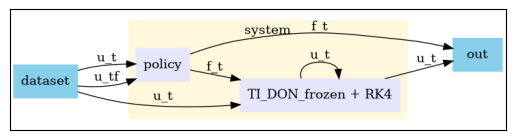

In [36]:
# closed-loop system model using the frozen TI-DON dynamics
dt = float(np.asarray(dt).item())
fxRK4_frozen = integrators.RK4(deeponet_integrator, h=dt)
node_rk4_frozen = Node(
    fxRK4_frozen,
    ["u_t", "f_t"],
    ["u_t"],
    name="TI_DON_frozen + RK4",
)

system_dpc = System([policy, node_rk4_frozen], nsteps=nsteps)
system_dpc.show()

### Dimension checks to the `System`

In [37]:
## dimnension checks for DeepONet inputs and outputs
batch = next(iter(train_loader_policy))
for k, v in batch.items():
    if hasattr(v, "shape"):
        print(k, v.shape)
    else:
        print(k, type(v), v)


u_t torch.Size([75, 1, 100])
u_tf torch.Size([75, 101, 100])
trunk_inputs torch.Size([75, 100, 1])
name <class 'str'> train


Because `System` always keeps the initial state and appends the prediction each step.

With `nsteps`:

input `u_t` has shape `(B,1,100)` (the initial state)
after `nsteps` it appends the predicted `u_{t+nsteps}`
so output `u_t` becomes `(B,t+nsteps+1,100) = [u_t, u_{t+1}, ..., u_{t+nsteps}]`

In [38]:
tensor_batch = {k: v.to(device) for k, v in batch.items() if hasattr(v, "shape")}
assert tensor_batch["u_tf"].shape[1] >= system_dpc.nsteps + 1

system_dpc = system_dpc.to(device)
out = system_dpc(tensor_batch)
print("System out keys:", out.keys())
print("f_t out shape:", out["f_t"].shape)  # has u_t and u_t+1
print("u_t out shape:", out["u_t"].shape)  # has u_t and u_t+1
print("u_tf out shape:", out["u_tf"].shape)  # has u_t and u_t+1



System out keys: dict_keys(['u_t', 'u_tf', 'trunk_inputs', 'f_t'])
f_t out shape: torch.Size([75, 100, 4])
u_t out shape: torch.Size([75, 101, 100])
u_tf out shape: torch.Size([75, 101, 100])


## Tracking loss

### Loss function

A fully data-driven **terminal objective** is used.
The rollout produced by the policy and the TI-DON dynamics yields a final
state $u_N$.  
This state is compared to the desired terminal profile $u_N^{\text{ref}}$.

The loss is mean squared error (MSE):

$$
\mathcal{L}
=
\frac{1}{B n_x}
\sum_{j=1}^{B}
\sum_{i=1}^{n_x}
\left(
u_{N}^{i,j} - u_{N,\text{ref}}^{i,j}
\right)^2.
$$

Here:

- $B$ → batch size  
- $n_x$ → number of spatial grid points  
- $u_N$ → predicted final state from the RK4 rollout  
- $u_{N,\text{ref}}$ → target final state

---

### Relation to the rollout

The terminal state is obtained recursively from the learned dynamics:

$$
u_{k+1} = \mathrm{RK4}\big(\mathcal{G}_\theta, u_k, a_k\big),
\qquad
a_k = \pi_{\mathbf{W}}(u_k, \xi_k).
$$

Although the loss is evaluated only at $k=N$, gradients propagate through
all intermediate steps.

In [39]:
# Terminal loss: MSE between predicted final state and true final state
y = variable("u_t")[:, -1, :]  # (B, T+1, nx)
r = variable("u_tf")[:, -1, :]  # (B, T+1, nx)

track = (y - r) ** 2
mse_obj = Objective(track, metric=torch.mean, name="mse_loss")

loss = PenaltyLoss(objectives=[mse_obj], constraints=[])


In [40]:
problem = Problem([system_dpc], loss)

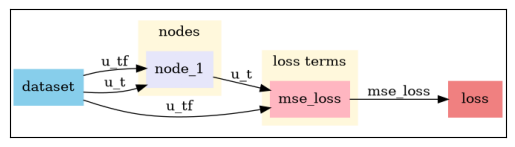

In [41]:
# plot computational graph
problem.show()

## Training the control policy

In [42]:
# result_dir = './'
epochs_dpc = int(10)  # 10 (epochs_dpc) passes of 100 (steps_per_epoch) steps each
log_every = 10 # log every 10 epoch
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

In [43]:
dpc_trainable_params = [p for p in problem.parameters() if p.requires_grad]
if not dpc_trainable_params:
    raise RuntimeError("No trainable DPC parameters found. Check policy/dynamics freezing.")

optimizer_dpc = torch.optim.Adam(dpc_trainable_params, lr=lr)
scheduler_dpc = LambdaLR(optimizer_dpc, lr_lambda=exponential_decay)

### Construct Trainer and solve the problem

In [44]:
# from neuromancer.trainer import Trainer

lr_callback_dpc = StepLRSchedulerCallback(scheduler_dpc, log_every=log_every)  # set as needed

trainer = Trainer(
    problem.to(device),
    train_data=train_loader_policy,
    # dev_data=dev_loader,        # optional
    test_data=test_loader_policy,
    optimizer=optimizer_dpc,
    callback=lr_callback_dpc,
    epochs=epochs_dpc,
    epoch_verbose=1,
    train_metric="train_loss",
    dev_metric="train_loss",  # or "dev_loss" if you use dev_data
    eval_metric="train_loss",
    test_metric="test_loss",
    warmup=epochs_dpc,
    device=device,
)

Sanity checks for grad passing in `policyMLP`, `tidon` and `loss`. `tidon` should be off as the dynamics model is frozen.

In [45]:
print(
    "policy params require grad:", any(p.requires_grad for p in policyMLP.parameters())
)
print("model params require grad:", any(p.requires_grad for p in tidon.parameters()))

batch = next(iter(train_loader_policy))

batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
# batch.pop("f_t", None)  # remove dataset controls
print(batch.keys())


policy params require grad: True
model params require grad: False
dict_keys(['u_t', 'u_tf', 'trunk_inputs', 'name'])


In [46]:
out = problem(batch)
print(out.keys())  # e.g. "train_loss" if name == "train"
print("loss requires grad:", out["train_loss"].requires_grad)

dict_keys(['train_u_t', 'train_u_tf', 'train_trunk_inputs', 'train_name', 'train_f_t', 'train_134833074715152', 'train_134833124410048', 'train_134833074383968', 'train_134833074379648', 'train_134833123299440', 'train_134833123299440_<built-in method mean of type object at 0x7aa5a1bd6c20>', 'train_objective_loss', 'train_penalty_loss', 'train_loss'])
loss requires grad: True


Train the model

In [47]:
%%time
best_dpc_model = trainer.train()

epoch: 0 step: 0 train_loss: 1.46832 lr: 1.00e-03
epoch: 0 step: 10 train_loss: 0.21105 lr: 9.99e-04
epoch: 0 step: 20 train_loss: 0.122536 lr: 9.99e-04
epoch: 0 step: 30 train_loss: 0.09315 lr: 9.98e-04
epoch: 0 step: 40 train_loss: 0.0884866 lr: 9.98e-04
epoch: 0 step: 50 train_loss: 0.0406634 lr: 9.97e-04
epoch: 0 step: 60 train_loss: 0.030394 lr: 9.97e-04
epoch: 0 step: 70 train_loss: 0.0406906 lr: 9.96e-04
epoch: 0 step: 80 train_loss: 0.0166279 lr: 9.96e-04
epoch: 0 step: 90 train_loss: 0.0273795 lr: 9.95e-04
epoch: 0  train_loss: 0.1201125904917717
epoch: 1 step: 0 train_loss: 0.0197374 lr: 9.95e-04
epoch: 1 step: 10 train_loss: 0.0184399 lr: 9.94e-04
epoch: 1 step: 20 train_loss: 0.0172461 lr: 9.94e-04
epoch: 1 step: 30 train_loss: 0.0457158 lr: 9.93e-04
epoch: 1 step: 40 train_loss: 0.0141182 lr: 9.93e-04
epoch: 1 step: 50 train_loss: 0.0205049 lr: 9.92e-04
epoch: 1 step: 60 train_loss: 0.0461887 lr: 9.92e-04
epoch: 1 step: 70 train_loss: 0.0277961 lr: 9.91e-04
epoch: 1 step: 

In [48]:
# load best trained model
trainer.dev_data = trainer.train_data  # workaround for replacing dev set to match keys
# best_outputs = trainer.test(best_dpc_model) # optional test evaluation
problem.load_state_dict(best_dpc_model)

<All keys matched successfully>

In [49]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
# mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
# print(f"mean_test_loss: {mean_test_loss}")
print(f"len(train_loss_history): {len(train_loss_history)}")


len(train_loss_history): 10


## Plot loss history w/ mean test loss

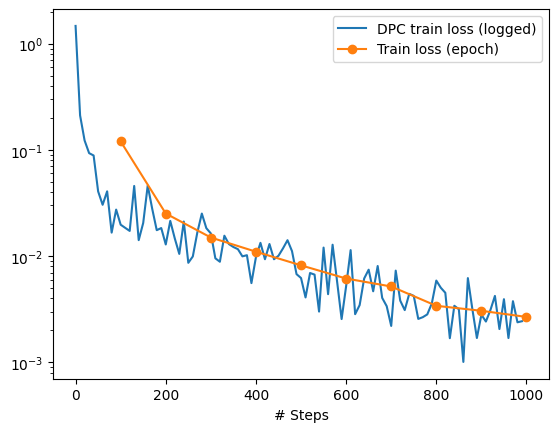

In [50]:
epoch_steps = (np.arange(len(train_loss_history)) + 1) * steps_per_epoch

plt.semilogy(
    lr_callback_dpc.step_indices,
    lr_callback_dpc.step_losses,
    label="DPC train loss (logged)"
)
plt.semilogy(epoch_steps, train_loss_history, "o-", label="Train loss (epoch)")

# plt.scatter(
#     epoch_steps[-1],
#     mean_test_loss,
#     label="Mean test loss",
#     c="red",
#     marker="x",
# )

plt.xlabel("# Steps")
plt.legend()
plt.show()


## Test time predictions

In [51]:
def predict_ct(u_t, u_tf, policy_node, key="u_tf"):
    # policy_node is a Neuromancer Node
    out = policy_node({"u_t": u_t, key: u_tf})
    return out["f_t"]


def loss_test_fn_physical(
    policy_node,
    x_cord,
    test_inits,
    test_finals,
    rollout_steps=400,
    policy_key="u_tf",  # or "outputs"
):
    """Roll out a Crank–Nicolson PDE solver with Gaussian actuator forcing."""
    policy_net = policy_node.callable
    policy_device = next(policy_net.parameters()).device
    policy_dtype = next(policy_net.parameters()).dtype

    u_t0 = test_inits.detach()
    u_tf = test_finals.detach()
    if u_t0.dim() == 1:
        u_t0 = u_t0.unsqueeze(0)
    if u_tf.dim() == 1:
        u_tf = u_tf.unsqueeze(0)

    u_t0_cpu = u_t0.detach().cpu().to(dtype=torch.float64)
    u_tf_cpu = u_tf.detach().cpu().to(dtype=torch.float64)

    x = x_cord.detach().cpu().to(dtype=torch.float64).reshape(-1)
    n_points = int(x.shape[0])
    dx = 1.0 / n_points

    nu = 0.1
    sigma = 0.1
    centers = torch.tensor([0.2, 0.4, 0.6, 0.8], device=x.device, dtype=torch.float64)
    fixed_dt = 0.001

    r = nu * fixed_dt / (2 * dx**2)
    main_diag = torch.ones(n_points, device=x.device, dtype=torch.float64) * (1 + 2 * r)
    off_diag = torch.ones(n_points - 1, device=x.device, dtype=torch.float64) * (-r)
    main_diag[0] = 1.0
    main_diag[-1] = 1.0
    off_diag[0] = 0.0
    if off_diag.numel() > 1:
        off_diag[-2] = 0.0

    A = torch.diag(main_diag)
    A = A + torch.diag(off_diag, diagonal=-1) + torch.diag(off_diag, diagonal=1)

    gaussian_basis = torch.exp(-0.5 * ((x[None, :] - centers[:, None]) / sigma) ** 2)

    def solve_step_implicit(u, f):
        rhs = u.clone()
        rhs[:, 1:-1] += r * (u[:, 2:] - 2 * u[:, 1:-1] + u[:, :-2])
        rhs = rhs + fixed_dt * f
        rhs[:, 0] = 0.0
        rhs[:, -1] = 0.0
        u_next = torch.linalg.solve(A, rhs.T).T
        return u_next

    traj_pred = []
    controls_pred = []
    u_t_cpu = u_t0_cpu
    u_t_policy = u_t0.to(device=policy_device, dtype=policy_dtype)
    u_tf_policy = u_tf.to(device=policy_device, dtype=policy_dtype)

    with torch.no_grad():
        for _ in range(int(rollout_steps)):
            c_t = predict_ct(u_t_policy, u_tf_policy, policy_node, key=policy_key)
            c_t_cpu = c_t.detach().to(device="cpu", dtype=torch.float64)
            f = c_t_cpu @ gaussian_basis
            u_next_cpu = solve_step_implicit(u_t_cpu, f)
            traj_pred.append(u_next_cpu.clone())
            controls_pred.append(c_t_cpu.clone())
            u_t_cpu = u_next_cpu
            u_t_policy = u_next_cpu.to(device=policy_device, dtype=policy_dtype)

    traj_pred = torch.stack(traj_pred, dim=0)
    controls_pred = torch.stack(controls_pred, dim=0)
    u_pred_final = traj_pred[-1]
    loss_pred = torch.mean((u_pred_final - u_tf_cpu) ** 2)

    traj_zero = []
    u_t_cpu = u_t0_cpu
    with torch.no_grad():
        for _ in range(int(rollout_steps)):
            f = torch.zeros_like(u_t_cpu)
            u_next_cpu = solve_step_implicit(u_t_cpu, f)
            traj_zero.append(u_next_cpu.clone())
            u_t_cpu = u_next_cpu

    traj_zero = torch.stack(traj_zero, dim=0)
    return (
        traj_pred.to(dtype=torch.float32),
        traj_zero.to(dtype=torch.float32),
        controls_pred.to(dtype=torch.float32),
        u_t0_cpu.to(dtype=torch.float32),
        u_tf_cpu.to(dtype=torch.float32),
        loss_pred.to(dtype=torch.float32),
    )


**Plotting routine**

Plots the spatial rollout $u(x,t)$ for zero control versus the learned policy, including the initial state $u_{t0}$ and target $u_{tf}$.

If provided, the actuator amplitudes $f_i(t)$ are shown in a third panel.


In [52]:
def plot_rollout_comparison(
    x_cord, traj_pred, traj_zero, u_t0, u_tf, control_pred=None, step=20
):
    """Plot rollout comparison panels for zero vs predicted control trajectories."""
    x = np.array(x_cord).squeeze()
    traj_pred = np.array(traj_pred)
    traj_zero = np.array(traj_zero)
    u_t0 = np.array(u_t0)
    u_tf = np.array(u_tf)

    t_pred, _ = traj_pred.shape
    t_zero = traj_zero.shape[0]

    plot_indices_pred = list(range(0, t_pred, int(step)))
    if (t_pred - 1) not in plot_indices_pred:
        plot_indices_pred.append(t_pred - 1)

    plot_indices_zero = list(range(0, t_zero, int(step)))
    if (t_zero - 1) not in plot_indices_zero:
        plot_indices_zero.append(t_zero - 1)

    cmap = plt.get_cmap("RdBu_r")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    ax1, ax2, ax3 = axes

    label_fs = 20
    title_fs = 22
    tick_fs = 18
    legend_fs = 18

    for t in plot_indices_zero:
        color = cmap(t / (t_zero - 1))
        lw = 3 if t in [0, t_zero - 1] else 1.4
        alpha = 1.0 if t in [0, t_zero - 1] else 0.7
        ax1.plot(x, traj_zero[t], color=color, lw=lw, alpha=alpha)

    ax1.plot(x, u_t0, "k--", lw=2.5, label="Initial $u_{t0}$")
    ax1.plot(x, u_tf, "k:", lw=2.5, label="True $u_{tf}$")
    ax1.set_title("Evolution (Control = 0)", fontsize=title_fs)
    ax1.set_xlabel("x", fontsize=label_fs)
    ax1.set_ylabel("u(x)", fontsize=label_fs)
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=legend_fs, loc="best")
    ax1.tick_params(axis="both", labelsize=tick_fs)

    for t in plot_indices_pred:
        color = cmap(t / (t_pred - 1))
        lw = 3 if t in [0, t_pred - 1] else 1.4
        alpha = 1.0 if t in [0, t_pred - 1] else 0.7
        ax2.plot(x, traj_pred[t], color=color, lw=lw, alpha=alpha)

    ax2.plot(x, u_t0, "k--", lw=2.5, label="Initial $u_{t0}$")
    ax2.plot(x, u_tf, "k:", lw=2.5, label="True $u_{tf}$")
    ax2.set_title("Evolution (Predicted Control)", fontsize=title_fs)
    ax2.set_xlabel("x", fontsize=label_fs)
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=legend_fs, loc="best")
    ax2.tick_params(axis="both", labelsize=tick_fs)

    if control_pred is not None:
        control_pred = np.array(control_pred)
        t_ctrl, num_ctrl = control_pred.shape
        time = np.arange(t_ctrl)
        colors = plt.cm.tab10(np.linspace(0, 1, num_ctrl))
        for c in range(num_ctrl):
            ax3.plot(
                time, control_pred[:, c], lw=2.5, color=colors[c], label=f"f {c + 1}"
            )

        ax3.set_title("Predicted Control Signals", fontsize=title_fs, pad=15)
        ax3.set_xlabel("Time step", fontsize=label_fs)
        ax3.set_ylabel("Control amplitude", fontsize=label_fs, labelpad=10)
        ax3.grid(alpha=0.3)
        ax3.tick_params(axis="both", labelsize=tick_fs)

        box = ax3.get_position()
        ax3.set_position([box.x0, box.y0, box.width * 0.85, box.height])
        ax3.legend(
            fontsize=legend_fs, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1
        )
    else:
        ax3.axis("off")
        ax3.text(
            0.5,
            0.5,
            "No control data provided",
            ha="center",
            va="center",
            fontsize=label_fs,
            color="gray",
        )

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()


### Why `System` makes autoregressive rollouts cleaner

Using `System` streamlines multi‑step inference because it **owns the rollout loop**. You set `system.nsteps`, pass a single batched input (`u_t`, `f_t`), and get the full trajectory back in one call.

With `System`, multi‑step rollout becomes a **single forward pass** instead of a custom loop, which is cleaner, less error‑prone, and easier to maintain.


In [53]:
num_eval_samples = 5  # set to 2 for quick visualization; increase as needed
rollout_steps = nsteps  # or horizon

# test_idx is a 1D index tensor or list
test_inits = inits[test_idx]
test_finals = finals[test_idx]

Forward pass and dimensions check

In [54]:
system_dpc = system_dpc.to(device)
system_dpc.nsteps = nsteps

u_t0 = test_inits[:, None, :].to(device)  # (B, 1, nx)
u_tf_seq = test_finals[:, None, :].repeat(1, nsteps + 1, 1).to(device)  # (B, T+1, nx)

test_data = {
    "u_t": u_t0,
    "u_tf": u_tf_seq,
}

trajectories = system_dpc(test_data)
print(trajectories.keys())
print(trajectories["u_t"].shape)  # (B, nsteps+1, nx)

dict_keys(['u_t', 'u_tf', 'f_t'])
torch.Size([20, 101, 100])


### Plotting and comparison with the zero control scenario


=== Plotting sample 15 ===


/home/pk222/neuromancer/.venv/lib/python3.12/site-packages/torchdiffeq/_impl/adjoint.py:196: UserWarning: An adjoint parameter was passed without requiring gradient. For efficiency this will be excluded from the adjoint pass, and will not appear as a tensor in the adjoint norm.
  warnings.warn("An adjoint parameter was passed without requiring gradient. For efficiency this will be "


Shapes: (1, 101, 100) (101, 1, 100) (1, 100, 4) (1, 100) (1, 100) Loss (extended): 0.0017706620274111629 Loss (physical): 0.000543954607564956


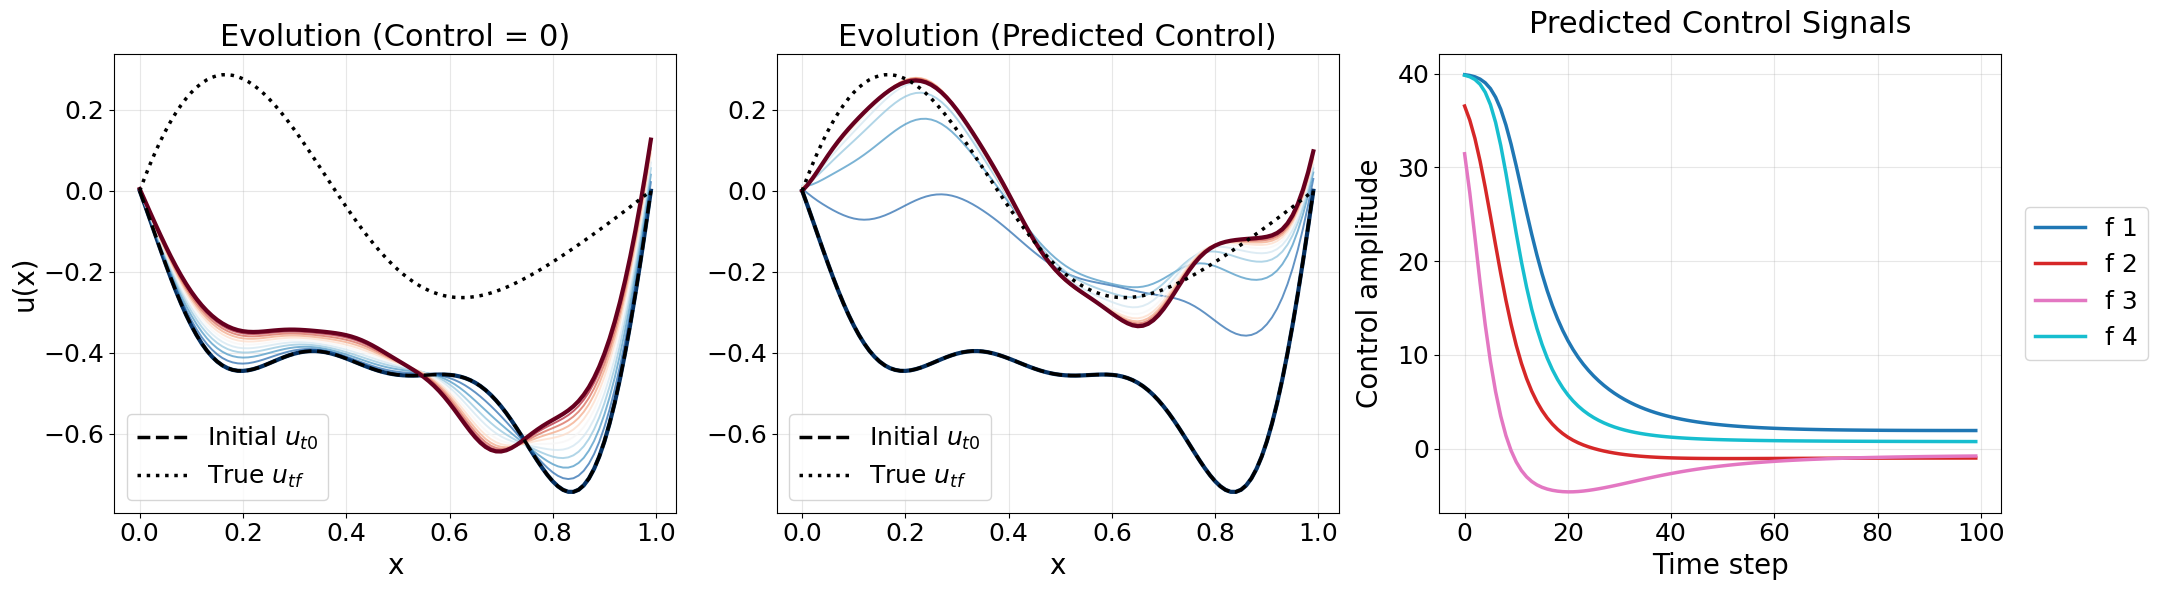


=== Plotting sample 16 ===
Shapes: (1, 101, 100) (101, 1, 100) (1, 100, 4) (1, 100) (1, 100) Loss (extended): 0.001825271057896316 Loss (physical): 0.0005180849693715572


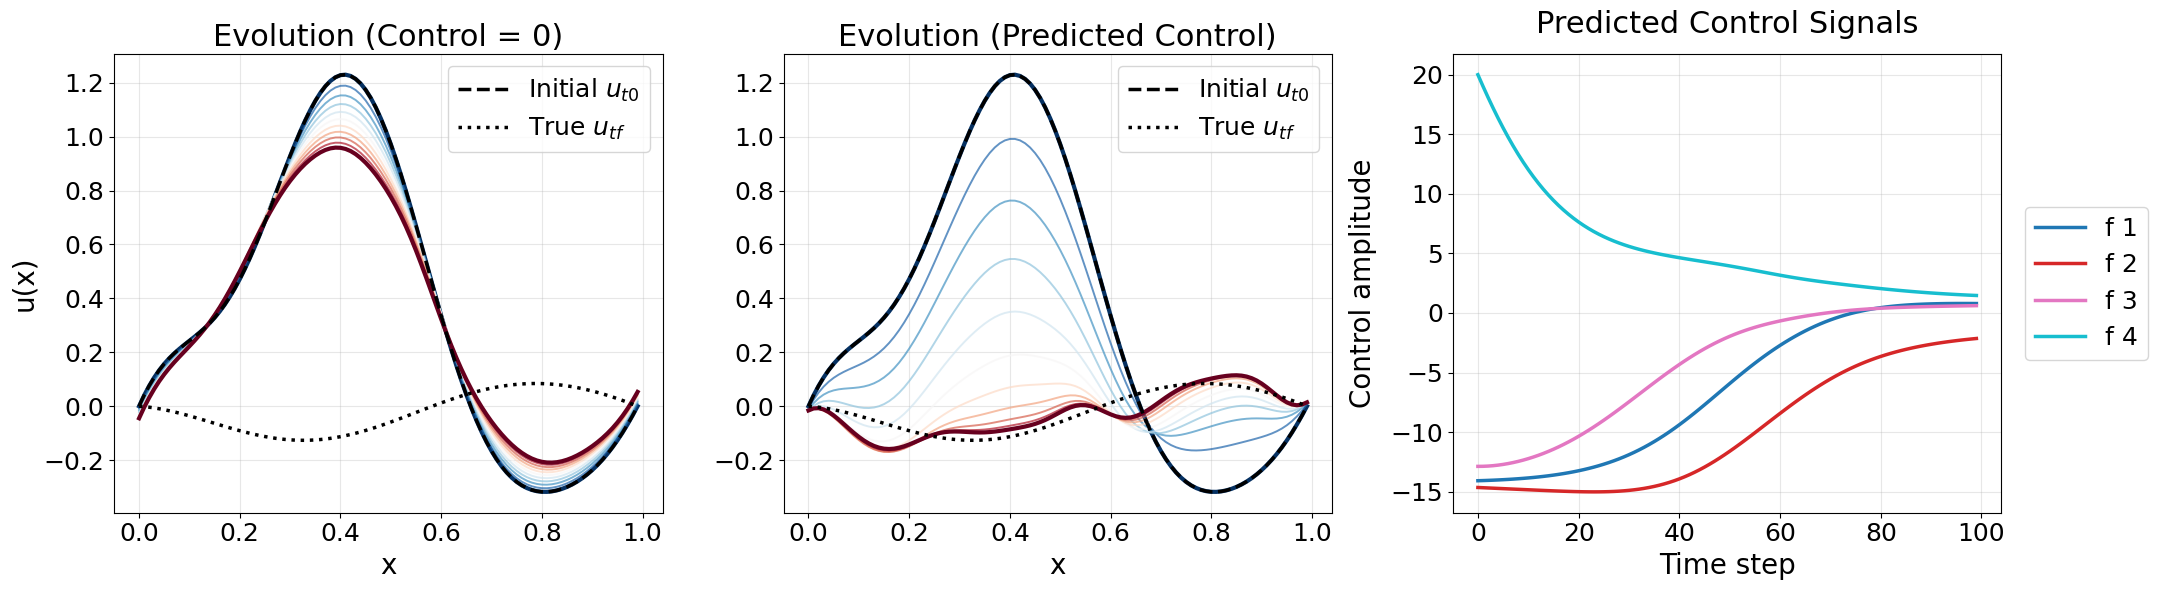


=== Plotting sample 14 ===
Shapes: (1, 101, 100) (101, 1, 100) (1, 100, 4) (1, 100) (1, 100) Loss (extended): 0.005842524114996195 Loss (physical): 0.004881757777184248


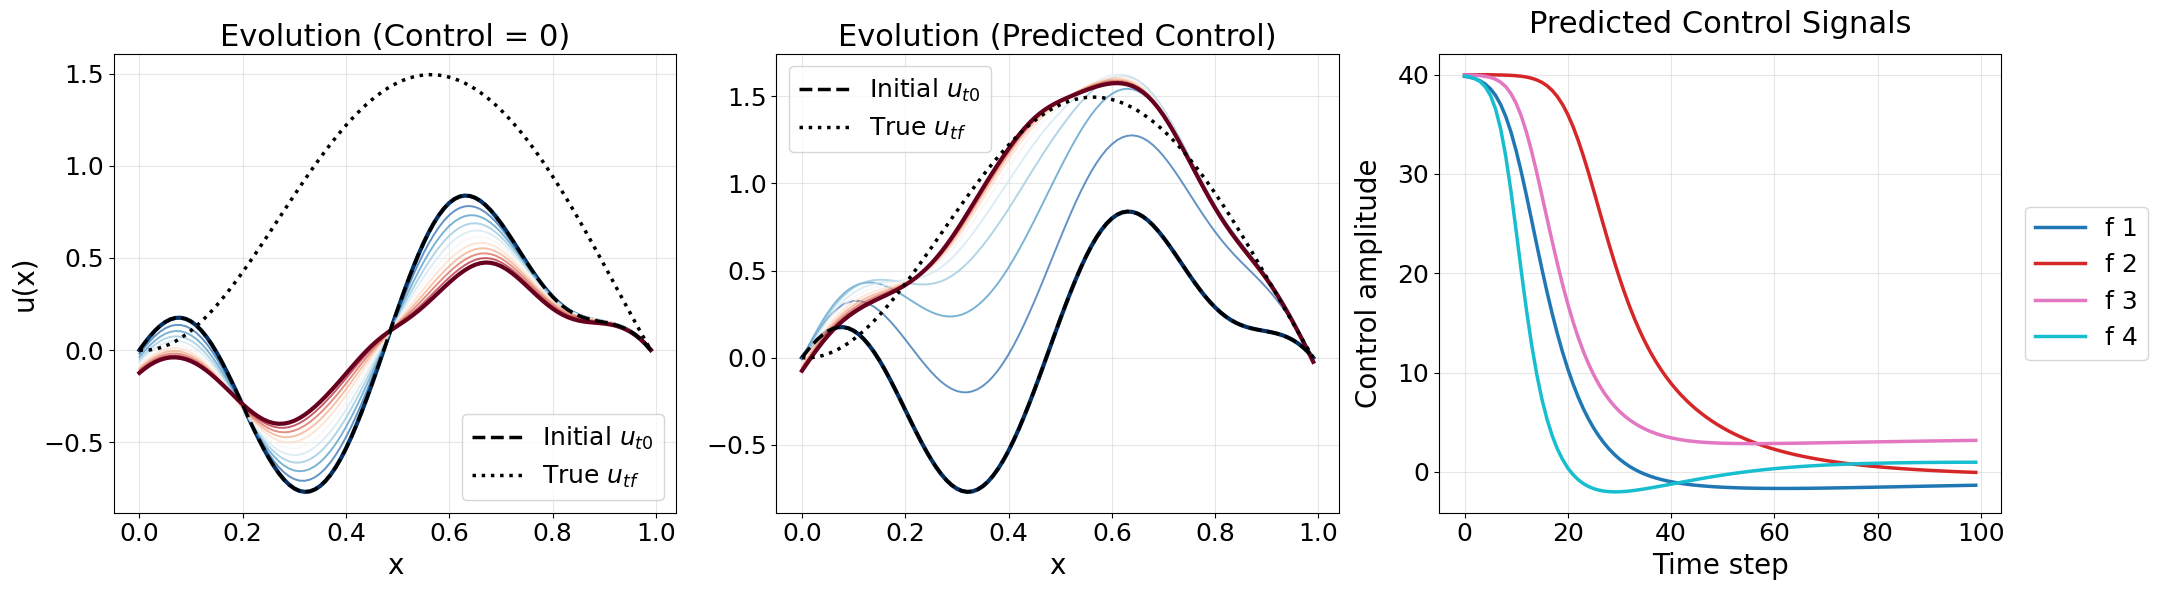


=== Plotting sample 17 ===
Shapes: (1, 101, 100) (101, 1, 100) (1, 100, 4) (1, 100) (1, 100) Loss (extended): 0.0012904624454677105 Loss (physical): 0.00035154540091753006


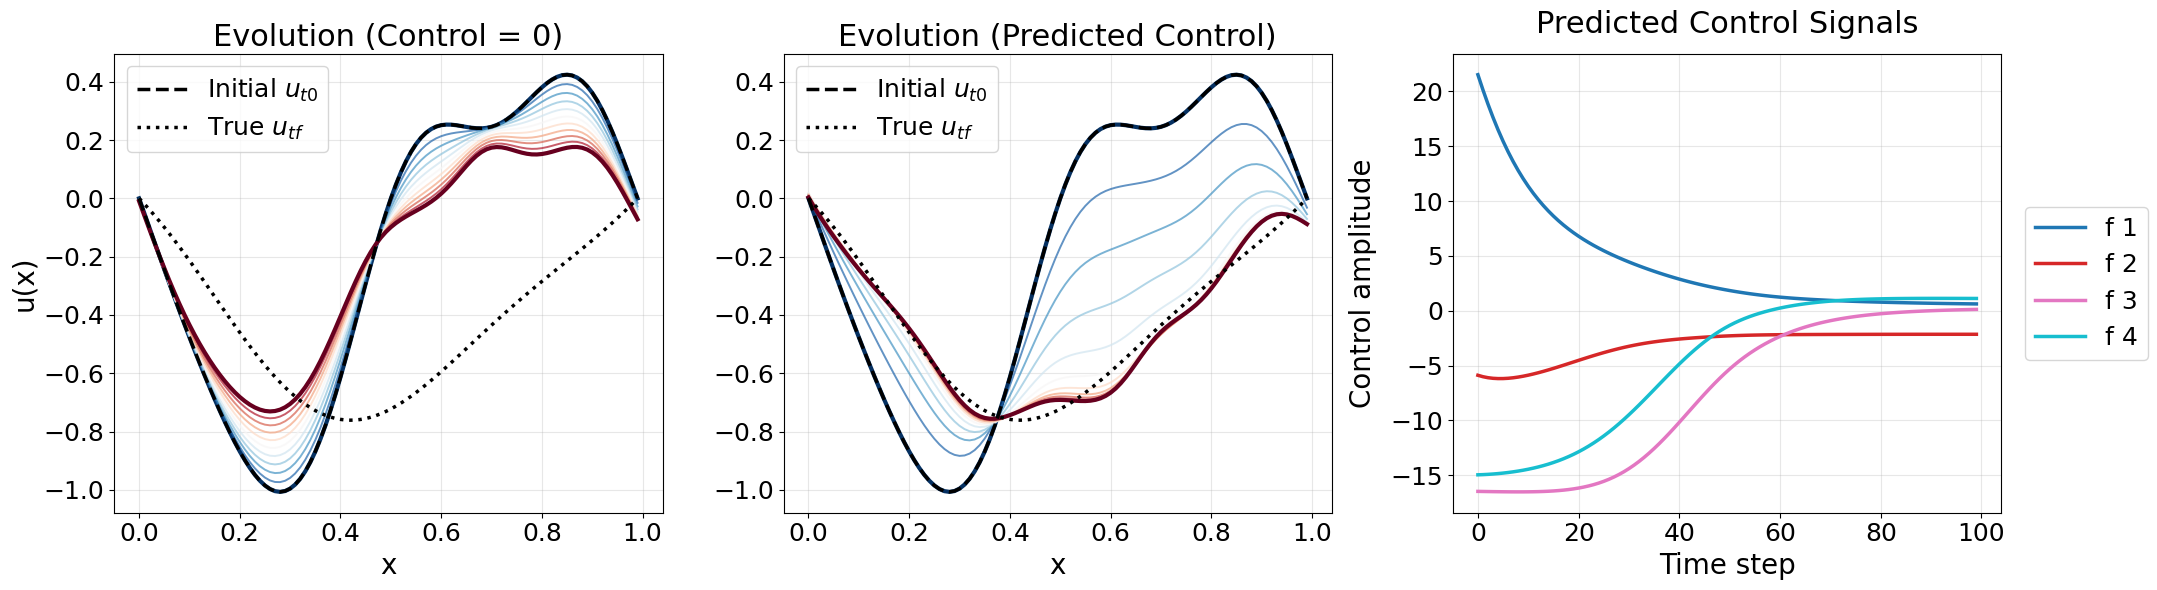


=== Plotting sample 1 ===
Shapes: (1, 101, 100) (101, 1, 100) (1, 100, 4) (1, 100) (1, 100) Loss (extended): 0.003439982421696186 Loss (physical): 0.002693205839022994


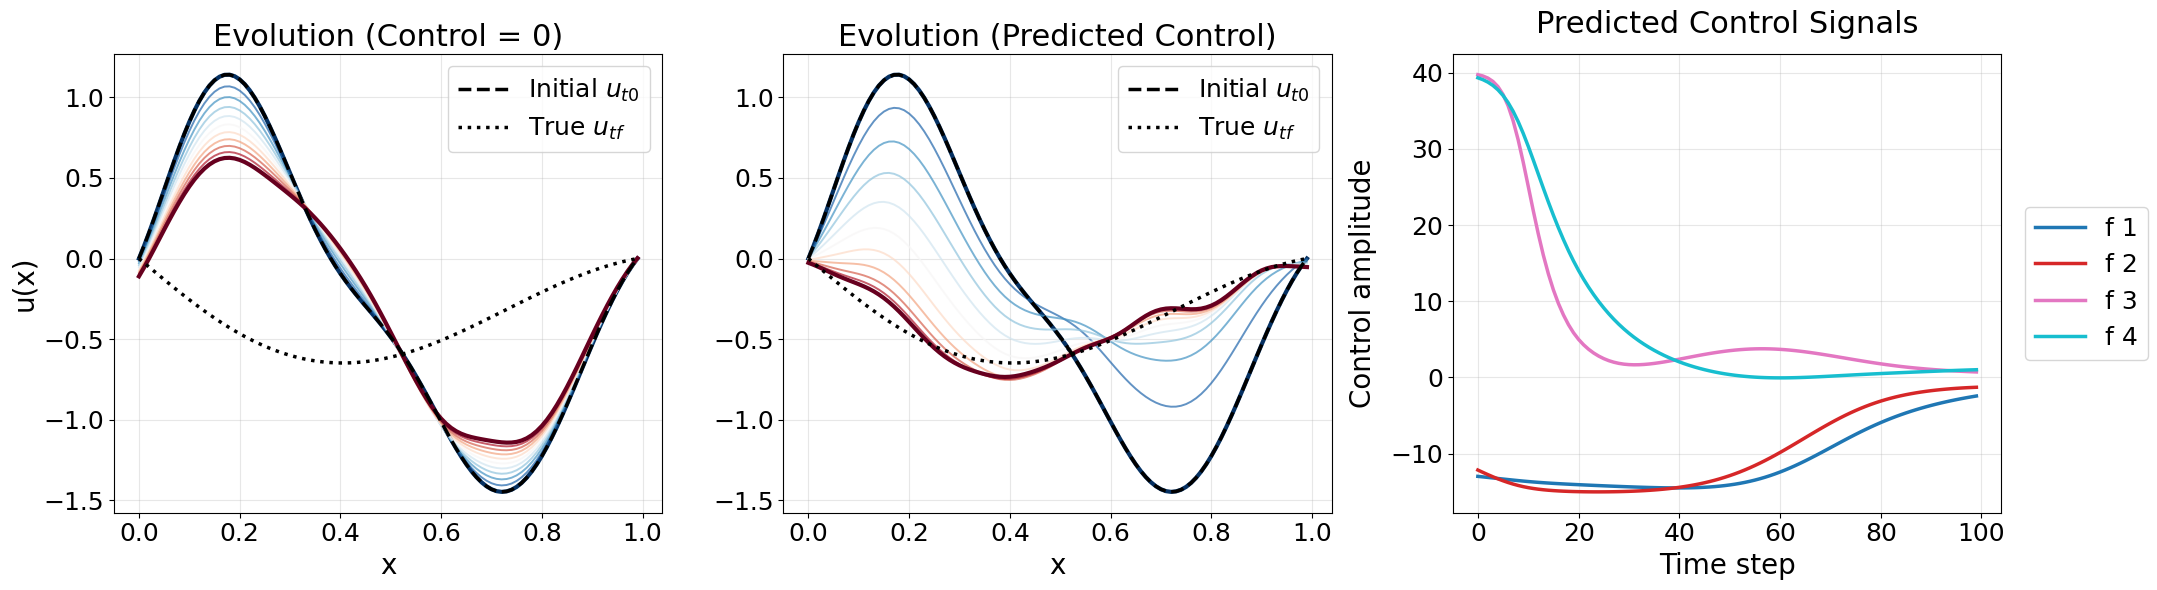

In [55]:
with torch.no_grad():
    num_eval = min(num_eval_samples, test_inits.shape[0])
    eval_indices = torch.randperm(test_inits.shape[0], device="cpu")[:num_eval].tolist()

    for i, idx in enumerate(eval_indices):
        print(f"\n=== Plotting sample {idx} ===")

        u0 = test_inits[idx : idx + 1].to(device)  # (1, nx)
        u_tf = test_finals[idx : idx + 1].to(device)  # (1, nx)

        # system inputs
        u_t0 = u0[:, None, :]  # (1, 1, nx)
        u_tf_seq = u_tf[:, None, :].repeat(1, rollout_steps + 1, 1)

        test_data = {"u_t": u_t0, "u_tf": u_tf_seq}

        # policy rollout (system_dpc)
        trajectories = system_dpc(test_data)
        traj_pred = trajectories["u_t"]  # (1, T+1, nx)
        controls_pred = trajectories.get("f_t")  # (1, T, nu)

        # # zero-control rollout (baseline)
        u_t = u0
        traj_zero = []
        for _ in range(int(rollout_steps)):
            c_t = torch.zeros_like(controls_pred[:, 0, :])
            u_t = node_rk4.callable(u_t, c_t)
            traj_zero.append(u_t)
        traj_zero = torch.stack(traj_zero, dim=0)  # (T, 1, nx)
        traj_zero = torch.cat([u0[None, ...], traj_zero], dim=0)  # (T+1, 1, nx)

        # terminal loss (extended)
        loss_extended = torch.mean((traj_pred[:, -1, :] - u_tf) ** 2)

        # physical PDE rollout
        (
            traj_pred_phys,
            traj_zero_phys,
            controls_pred_phys,
            u_t0_phys,
            u_tf_phys,
            loss_physical,
        ) = loss_test_fn_physical(policy, x_cord, u0, u_tf, rollout_steps=rollout_steps)

        # boundary checks (physical)
        if not torch.isclose(u_t0_phys[0, 0], torch.tensor(0.0), atol=1e-6):
            print("Warning: u_t0 boundary at x=0 is not zero (physical).")
        if not torch.isclose(u_t0_phys[0, -1], torch.tensor(0.0), atol=1e-6):
            print("Warning: u_t0 boundary at x=1 is not zero (physical).")
        if not torch.isclose(traj_pred_phys[-1, 0, 0], torch.tensor(0.0), atol=1e-6):
            print("Warning: physical rollout boundary at x=0 is not zero.")
        if not torch.isclose(traj_pred_phys[-1, 0, -1], torch.tensor(0.0), atol=1e-6):
            print("Warning: physical rollout boundary at x=1 is not zero.")

        print(
            "Shapes:",
            tuple(traj_pred.shape),
            tuple(traj_zero.shape),
            tuple(controls_pred.shape),
            tuple(u_t0[0].shape),
            tuple(u_tf.shape),
            "Loss (extended):",
            float(loss_extended),
            "Loss (physical):",
            float(loss_physical),
        )

        # plots
        plot_rollout_comparison(
            x_cord=x_cord.cpu().numpy().squeeze(),
            traj_pred=traj_pred[0].cpu().numpy(),
            traj_zero=traj_zero[:, 0, :].cpu().numpy(),
            u_t0=u0[0].cpu().numpy(),
            u_tf=u_tf[0].cpu().numpy(),
            control_pred=controls_pred[0].cpu().numpy(),
            step=max(1, nsteps // 10),
        )
